# Analyse globale — Assurance responsabilité civile automobile

J'unifie tout d'abord la table des contrats avec celle des sinistres, puis contrôle la qualité de la table obtenue.
Le plan global d'analyse est le suivant :
| Question métier | Indicateurs à analyser | Visuel envisagé |
|---|---|---|
| Où se concentrent les sinistres déclarés ? | Nombre et part des sinistres, contrats et exposition | Barres par segment |
| Où se concentrent les coûts observés ? | Montant observé, part du montant total, exposition | Barres par segment |
| Quels segments déclarent davantage de sinistres à exposition comparable ? | Fréquence, exposition, nombre de sinistres | Barres de fréquence avec volumes associés |
| Où les sinistres observés coûtent-ils davantage ? | Coût moyen et médian observés, nombre de sinistres renseignés | Tableau comparatif |
| Sur quels segments les résultats sont-ils moins fiables ? | Coûts manquants, faible exposition, écarts de rapprochement | Tableau qualité |

La suite se trouve dans [analyse_approfondie.ipynb](analyse_approfondie.ipynb) : sélection des groupes à fort volume et fréquence élevée, puis comparaison de leurs profils.

In [1]:
from pathlib import Path

# Retrouver le dossier du projet depuis la racine ou depuis notebook.
racine = Path.cwd()
if racine.name == 'notebook':
    racine = racine.parent

import pandas as pd
import numpy as np

colonnes_freq = [
    'IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge',
    'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'
]

# 14 lignes de description dans freq, 4 dans sev.
# quotechar retire les apostrophes autour des catégories.
df_freq = pd.read_csv(
    racine / 'data/raw/freMTPL2freq.arff', skiprows=14, names=colonnes_freq,
    quotechar="'", na_values='?', dtype={'IDpol': 'int64'}
)
df_sev = pd.read_csv(
    racine / 'data/raw/freMTPL2sev.arff', skiprows=4, names=['IDpol', 'ClaimAmount'],
    quotechar="'", na_values='?', dtype={'IDpol': 'int64'}
)


## 1. Unification des tables

In [2]:
# Mettre de côté les sinistres dont le contrat est absent de freq.
orphelins = ~df_sev['IDpol'].isin(df_freq['IDpol'])
df_sev_orphelins = df_sev.loc[orphelins].copy()
df_sev_rapprochable = df_sev.loc[~orphelins].copy()

# Regrouper les sinistres pour avoir une ligne par contrat.
df_agg_sev = (
    df_sev_rapprochable.groupby('IDpol', as_index=False)
        .agg(
            NbSinister=('IDpol', 'count'),
            TotalAmount=('ClaimAmount', 'sum')
        )
)

# Garder tous les contrats de freq.
# validate vérifie qu'il y a une seule ligne par IDpol de chaque côté.
df_unified = pd.merge(
    df_freq, df_agg_sev, on='IDpol', how='left', validate='one_to_one'
)

# Conditions pour distinguer les situations après la jointure.
is_na = df_unified['NbSinister'].isna()
has_claim = df_unified['ClaimNb'] > 0
same_count = df_unified['ClaimNb'] == df_unified['NbSinister']

df_unified['Status'] = np.select(
    [is_na & has_claim,
     is_na & ~has_claim,
     ~is_na & has_claim & same_count,
     ~is_na & has_claim & ~same_count],
    ['Montant non retrouvé', 'Sans sinistre',
     'Nombre concordant', 'Nombre différent'],
    default='À vérifier'
)

# Contrôles de la table obtenue.
print("Nombre de contrats :", len(df_unified))
print("IDpol répétés :", df_unified['IDpol'].duplicated().sum())
print("Nombre total de sinistres déclaré :", df_unified['ClaimNb'].sum())
print("Exposition conservée :",
      df_unified['Exposure'].sum() == df_freq['Exposure'].sum())
print("Montant rapprochable conservé :",
      round(df_unified['TotalAmount'].sum(), 2)
      == round(df_sev_rapprochable['ClaimAmount'].sum(), 2))
print(df_unified['Status'].value_counts())

print("Contrats avec un nombre de sinistres différent :")
print(df_unified.loc[
    df_unified['Status'] == 'Nombre différent',
    ['IDpol', 'ClaimNb', 'NbSinister']
].to_string(index=False))

print("Contrats orphelins mis de côté :", df_sev_orphelins['IDpol'].nunique())
print("Lignes de sinistres mises de côté :", len(df_sev_orphelins))

Nombre de contrats : 678013
IDpol répétés : 0
Nombre total de sinistres déclaré : 36102
Exposition conservée : True
Montant rapprochable conservé : True
Status
Sans sinistre           643953
Nombre concordant        24943
Montant non retrouvé      9116
Nombre différent             1
Name: count, dtype: int64
Contrats avec un nombre de sinistres différent :
  IDpol  ClaimNb  NbSinister
4158255        2         1.0
Contrats orphelins mis de côté : 6
Lignes de sinistres mises de côté : 195


J'ai regroupé les sinistres par contrat, puis fait une jointure gauche pour conserver les **678 013 contrats de freq**.
Les **6 contrats orphelins (195 lignes)** sont gardés à part dans `df_sev_orphelins`.

Les `NaN` indiquent une absence de correspondance dans `sev` : **643 953 contrats sans sinistre** et **9 116 contrats sinistrés sans montant retrouvé**.
Je ne remplace pas les montants inconnus par zéro.

Parmi les contrats rapprochés, **24 943 ont un nombre de sinistres concordant**. Le contrat **4158255** en déclare **2**, contre **1 ligne dans sev**.
Je garde cet écart visible et je conserve `ClaimNb`.

# 2. Ajout des indicateurs clés

In [3]:
# Calculer les totaux du portefeuille.
nb_contrats = len(df_unified)
exposition_totale = df_unified['Exposure'].sum()
nb_sinistres_declares = df_unified['ClaimNb'].sum()
nb_sinistres_observes = df_unified['NbSinister'].sum()

# Additionner les montants disponibles, sans remplacer les NaN par zéro.
# min_count=1 garde un résultat NaN si aucun montant n'est disponible.
montant_observe = df_unified['TotalAmount'].sum(min_count=1)

# Calculer les ratios à partir des totaux.
frequence100 = nb_sinistres_declares / exposition_totale * 100
cout_moyen_observe = montant_observe / nb_sinistres_observes
cout_observe_par_annee = montant_observe / exposition_totale

# Mesurer la part des contrats sinistrés sans montant retrouvé.
nb_contrats_sinistres = (df_unified['ClaimNb'] > 0).sum()
nb_contrats_sans_montant = (df_unified['Status'] == 'Montant non retrouvé').sum()
part_sans_montant = nb_contrats_sans_montant / nb_contrats_sinistres * 100

# Une seule ligne pour résumer le portefeuille.
df_kpi = pd.DataFrame({
    'NbContrats': [nb_contrats],
    'ExpositionTotaleAnnees': [exposition_totale],
    'NbSinistresDeclares': [nb_sinistres_declares],
    'NbSinistresObserves': [nb_sinistres_observes],
    'MontantObserveEuros': [montant_observe],
    'FrequencePour100Annees': [frequence100],
    'CoutMoyenObserveEuros': [cout_moyen_observe],
    'CoutObserveParAnneeEuros': [cout_observe_par_annee],
    'PartContratsSinistresSansMontantPct': [part_sans_montant]
})

# .T affiche les KPI verticalement pour faciliter la lecture.
# df_kpi garde une seule ligne et les valeurs non arrondies.
print(df_kpi.round(2).T)

                                               0
NbContrats                             678013.00
ExpositionTotaleAnnees                 358499.45
NbSinistresDeclares                     36102.00
NbSinistresObserves                     26444.00
MontantObserveEuros                  59909216.50
FrequencePour100Annees                     10.07
CoutMoyenObserveEuros                    2265.51
CoutObserveParAnneeEuros                  167.11
PartContratsSinistresSansMontantPct        26.76


`df_kpi` contient une ligne pour tout le portefeuille. L'exposition est en années, les montants en euros
et la fréquence en sinistres pour 100 années d'exposition. Seule la part des contrats sans montant est exprimée en pourcentage.

Pour le coût moyen, je divise par le nombre de sinistres observés dans `sev`, et non par tous les sinistres déclarés dans `freq`.
Les coûts restent des **montants observés** : ils ne représentent pas la charge complète du portefeuille.
Le taux de montants non retrouvés ne compte pas le contrat dont le nombre de sinistres est différent ; cet écart reste signalé dans `Status`.

La part des montants de chaque segment sera calculée lors des comparaisons par segment.

# 3. Quels segments concentrent le nombre de sinistres ?

Je cherche les groupes qui représentent le plus grand nombre de sinistres déclarés.
J'utilise **ClaimNb**, qui compte les **36 102 sinistres déclarés dans freq**.
`NbSinister` compte seulement les sinistres retrouvés dans `sev` : il sert aux analyses des coûts observés.

Je garde aussi le nombre de contrats et l'exposition de chaque groupe pour la suite.
Un groupe qui compte beaucoup de sinistres peut simplement représenter une grande partie du portefeuille.

## 3.1. Comparaison des catégories

Je regarde le carburant, la zone, la marque codée et la région.
`Status` reste un indicateur de qualité des données.

Analyse par VehGas
 VehGas  NbContrats  NbSinistres  Exposition  PartSinistresPct
Regular      345877        19454   187838.55             53.89
 Diesel      332136        16648   170660.89             46.11
Contrats conservés : True
Sinistres conservés : True


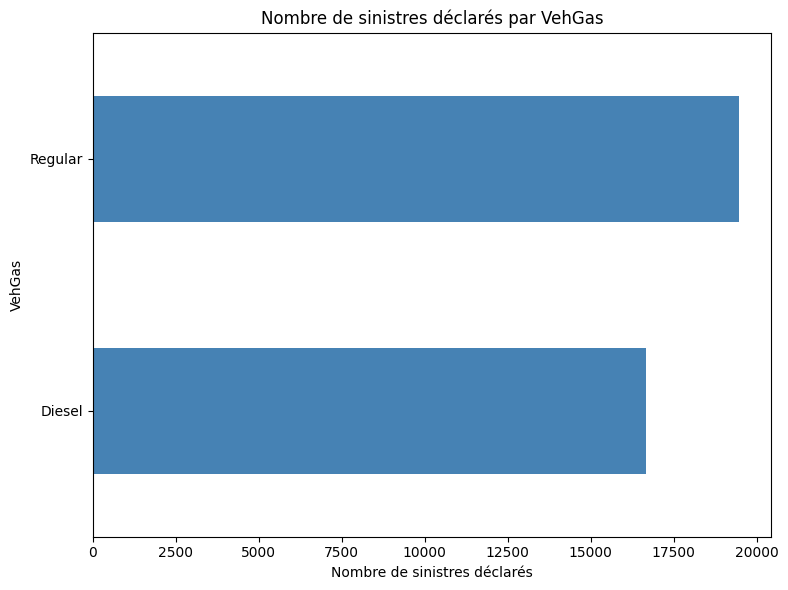

Analyse par Area
Area  NbContrats  NbSinistres  Exposition  PartSinistresPct
   C      191880         9875   104449.00             27.35
   D      151596         8428    77120.19             23.34
   E      137167         7805    63819.31             21.62
   A      103957         5063    61969.38             14.02
   B       75459         3800    43012.32             10.53
   F       17954         1131     8129.23              3.13
Contrats conservés : True
Sinistres conservés : True


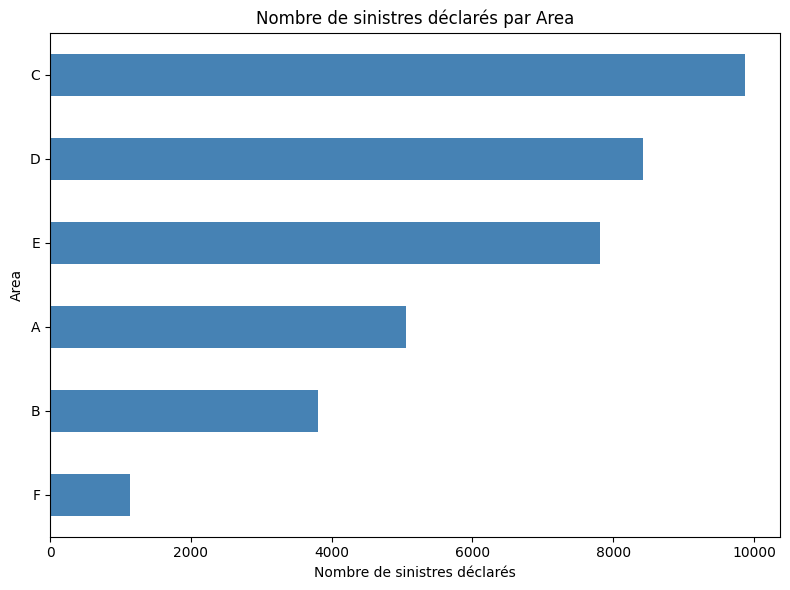

Analyse par VehBrand
VehBrand  NbContrats  NbSinistres  Exposition  PartSinistresPct
     B12      166024         8859    64808.61             24.54
      B1      162736         8677    95351.06             24.03
      B2      159861         8560    94864.06             23.71
      B3       53395         2818    28592.88              7.81
      B5       34753         2020    19992.06              5.60
      B6       28548         1462    15684.95              4.05
      B4       25179         1312    13775.50              3.63
     B10       17707          858     9496.01              2.38
     B11       13585          721     6887.82              2.00
     B13       12178          649     6772.03              1.80
     B14        4047          166     2274.47              0.46
Contrats conservés : True
Sinistres conservés : True


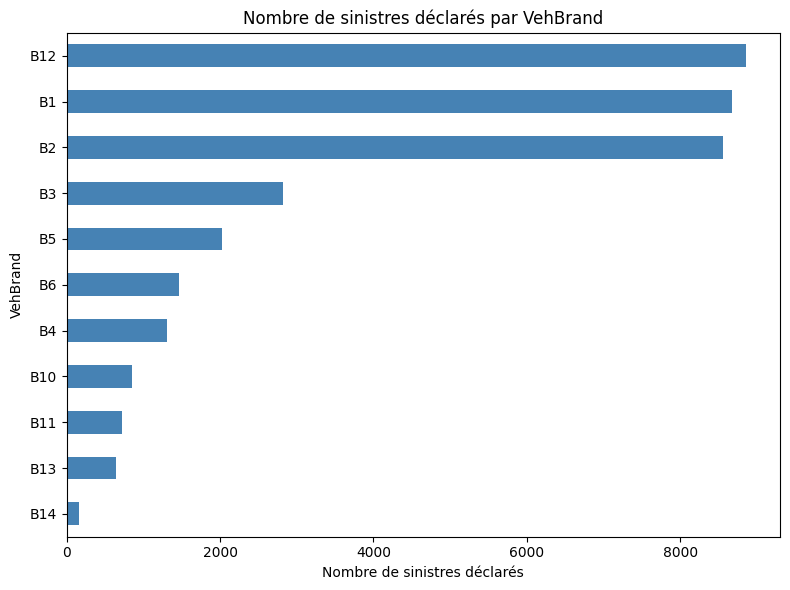

Analyse par Region
Region  NbContrats  NbSinistres  Exposition  PartSinistresPct
   R24      160601         9204   102712.90             25.49
   R82       84752         5032    45347.42             13.94
   R11       69791         3978    30208.64             11.02
   R93       79315         3907    35790.32             10.82
   R53       42122         2702    27753.46              7.48
   R52       38751         2010    21934.03              5.57
   R91       35805         1547    14736.10              4.29
   R72       31329         1348    14322.17              3.73
   R31       27285         1176    11497.97              3.26
   R54       19046          968    11163.41              2.68
   R73       17141          688     7020.11              1.91
   R25       10893          633     6657.90              1.75
   R41       12990          611     8113.78              1.69
   R26       10492          511     5025.36              1.42
   R22        7994          439     3574.41        

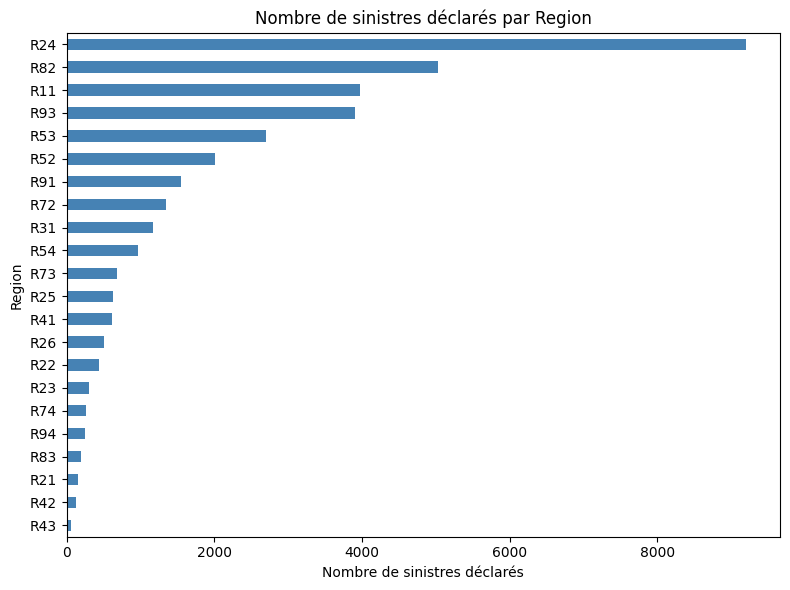

In [4]:
import matplotlib.pyplot as plt

segments_categories = ['VehGas', 'Area', 'VehBrand', 'Region']
tableaux_categories = {}  # Je garde les tableaux pour la suite de l'analyse.

for segment in segments_categories:
    # Regrouper les contrats selon la catégorie choisie.
    tableau = df_unified.groupby(segment, as_index=False).agg(
        NbContrats=('IDpol', 'count'),
        NbSinistres=('ClaimNb', 'sum'),
        Exposition=('Exposure', 'sum')
    )

    # Calculer la part des sinistres de chaque groupe dans le portefeuille.
    tableau['PartSinistresPct'] = tableau['NbSinistres'] / nb_sinistres_declares * 100
    tableau = tableau.sort_values('NbSinistres', ascending=False)
    tableaux_categories[segment] = tableau

    print("Analyse par", segment)
    print(tableau.round(2).to_string(index=False))
    print("Contrats conservés :", tableau['NbContrats'].sum() == nb_contrats)
    print("Sinistres conservés :", tableau['NbSinistres'].sum() == nb_sinistres_declares)

    # Un graphique simple, avec les groupes les plus importants en haut.
    tableau.plot.barh(
        x=segment, y='NbSinistres', legend=False,
        figsize=(8, 6), color='steelblue'
    )
    plt.title(f"Nombre de sinistres déclarés par {segment}")
    plt.xlabel("Nombre de sinistres déclarés")
    plt.ylabel(segment)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

**Premiers constats :**

- Le carburant **Regular** représente **19 454 sinistres**, soit **53,89 %** du total.
- La zone **C** concentre **27,35 %** des sinistres.
- La marque codée **B12** représente **24,54 %** des sinistres et la région **R24**, **25,49 %**.

Ces résultats montrent où se trouvent les volumes de sinistres.
Ils ne suffisent pas à dire que ces groupes ont une fréquence plus élevée : il faut aussi regarder leur exposition.

## 3.2. Création de tranches pour les valeurs numériques

Je regroupe les âges, le bonus-malus, la puissance et la densité pour faciliter la lecture.
Ce sont des tranches choisies pour cette analyse, pas des catégories officielles de l'assureur.

Avec `pd.cut`, la borne haute est incluse ici : une tranche de 24 à 34 contient donc les âges entiers de **25 à 34 ans**.
Les âges de 100 ans restent dans un groupe séparé, car leur signification est encore à vérifier.
`ClaimNb` reste l'indicateur à compter et `Exposure` servira à calculer la fréquence.

In [5]:
# Garder la table unifiée et créer une copie avec les tranches.
df_segments = df_unified.copy()

df_segments['TrancheAgeConducteur'] = pd.cut(
    df_segments['DrivAge'],
    bins=[17, 24, 34, 44, 54, 64, 74, 99, np.inf],
    labels=['18-24 ans', '25-34 ans', '35-44 ans', '45-54 ans',
            '55-64 ans', '65-74 ans', '75-99 ans', '100 ans et plus (à vérifier)']
)

df_segments['TrancheAgeVehicule'] = pd.cut(
    df_segments['VehAge'],
    bins=[-1, 0, 2, 5, 10, 20, 99, np.inf],
    labels=['0 an', '1-2 ans', '3-5 ans', '6-10 ans', '11-20 ans',
            '21-99 ans', '100 ans et plus (à vérifier)']
)

df_segments['TrancheBonusMalus'] = pd.cut(
    df_segments['BonusMalus'],
    bins=[0, 50, 75, 100, 125, 150, 200, np.inf],
    labels=['50 ou moins', '51-75', '76-100', '101-125',
            '126-150', '151-200', '201 et plus']
)

df_segments['TranchePuissance'] = pd.cut(
    df_segments['VehPower'],
    bins=[0, 5, 7, 9, 11, np.inf],
    labels=['5 ou moins', '6-7', '8-9', '10-11', '12 et plus']
)

df_segments['TrancheDensite'] = pd.cut(
    df_segments['Density'],
    bins=[0, 100, 500, 1000, 5000, 20000, np.inf],
    labels=['1-100', '101-500', '501-1 000', '1 001-5 000',
            '5 001-20 000', '20 001 et plus']
)

segments_tranches = [
    'TrancheAgeConducteur', 'TrancheAgeVehicule', 'TrancheBonusMalus',
    'TranchePuissance', 'TrancheDensite'
]

# Chaque contrat doit appartenir à une tranche pour chaque variable.
print("Contrats sans tranche attribuée :")
print(df_segments[segments_tranches].isna().sum())

Contrats sans tranche attribuée :
TrancheAgeConducteur    0
TrancheAgeVehicule      0
TrancheBonusMalus       0
TranchePuissance        0
TrancheDensite          0
dtype: int64


Analyse par TrancheAgeConducteur
        TrancheAgeConducteur  NbContrats  NbSinistres  Exposition  PartSinistresPct
                   18-24 ans       30198         2364    12489.16              6.55
                   25-34 ans      140947         6396    64598.61             17.72
                   35-44 ans      170578         8145    87391.45             22.56
                   45-54 ans      164034         9513    89852.75             26.35
                   55-64 ans       99094         5124    56176.95             14.19
                   65-74 ans       50821         2986    32207.19              8.27
                   75-99 ans       22338         1574    15781.60              4.36
100 ans et plus (à vérifier)           3            0        1.73              0.00
Contrats conservés : True
Sinistres conservés : True


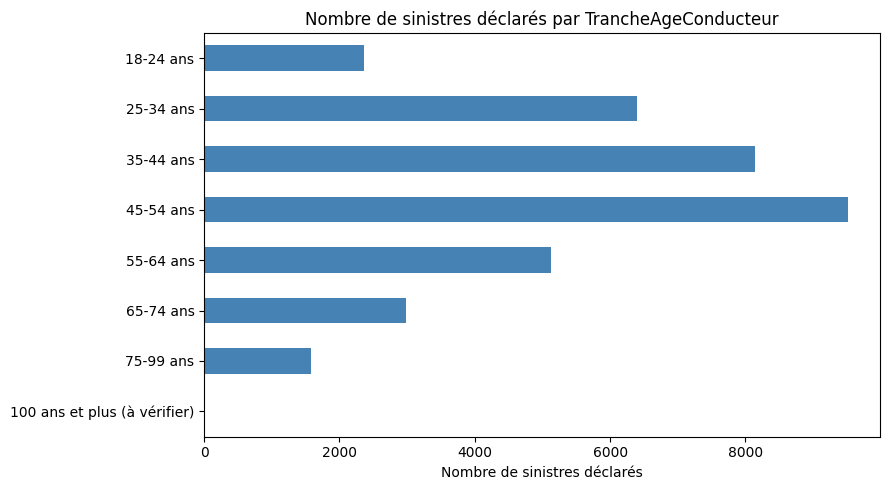

Analyse par

 TrancheAgeVehicule
          TrancheAgeVehicule  NbContrats  NbSinistres  Exposition  PartSinistresPct
                        0 an       57739         5205    16719.03             14.42
                     1-2 ans      130408         5699    62457.03             15.79
                     3-5 ans      132490         6743    72040.12             18.68
                    6-10 ans      171594         9846    99008.92             27.27
                   11-20 ans      177460         8333   103127.13             23.08
                   21-99 ans        8297          276     5132.07              0.76
100 ans et plus (à vérifier)          25            0       15.15              0.00
Contrats conservés : True
Sinistres conservés : True


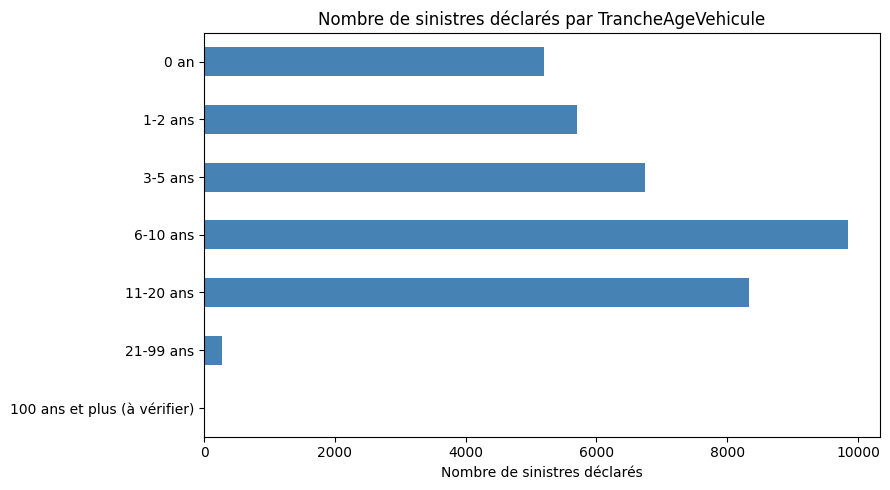

Analyse par TrancheBonusMalus
TrancheBonusMalus  NbContrats  NbSinistres  Exposition  PartSinistresPct
      50 ou moins      384156        18056   225233.13             50.01
            51-75      175012         9614    84874.66             26.63
           76-100      111051         7090    44820.34             19.64
          101-125        6987         1178     3198.27              3.26
          126-150         598          110      277.92              0.30
          151-200         205           52       94.34              0.14
      201 et plus           4            2        0.79              0.01
Contrats conservés : True
Sinistres conservés : True


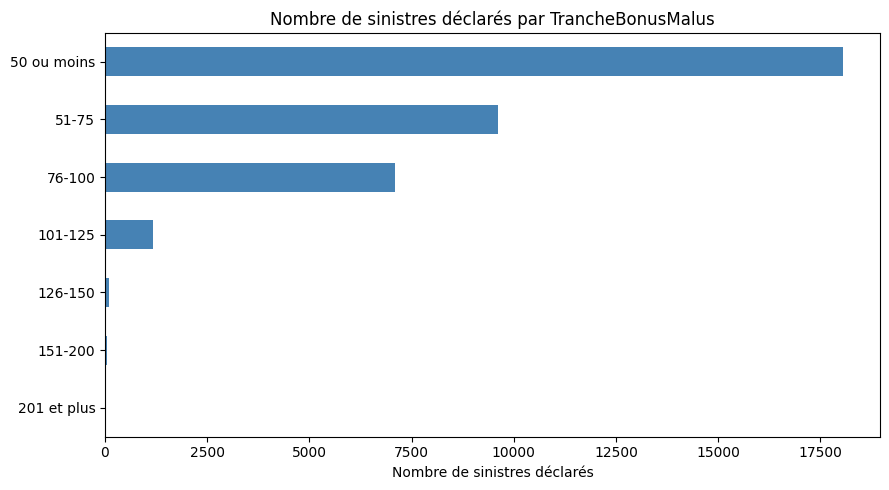

Analyse par TranchePuissance
TranchePuissance  NbContrats  NbSinistres  Exposition  PartSinistresPct
      5 ou moins      240170        12977   128246.99             35.95
             6-7      294377        16008   160474.67             44.34
             8-9       77041         3676    38032.83             10.18
           10-11       49706         2686    23872.79              7.44
      12 et plus       16719          755     7872.17              2.09
Contrats conservés : True
Sinistres conservés : True


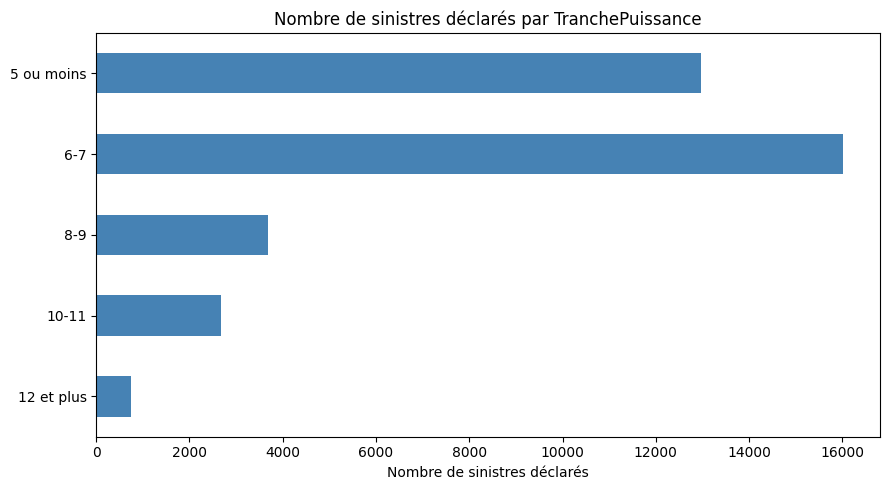

Analyse par

 TrancheDensite
TrancheDensite  NbContrats  NbSinistres  Exposition  PartSinistresPct
         1-100      179589         8873   105067.39             24.58
       101-500      191804         9874   104411.19             27.35
     501-1 000       72495         3974    36793.10             11.01
   1 001-5 000      184741        10434    89959.47             28.90
  5 001-20 000       38082         2213    17026.16              6.13
20 001 et plus       11302          734     5242.14              2.03
Contrats conservés : True
Sinistres conservés : True


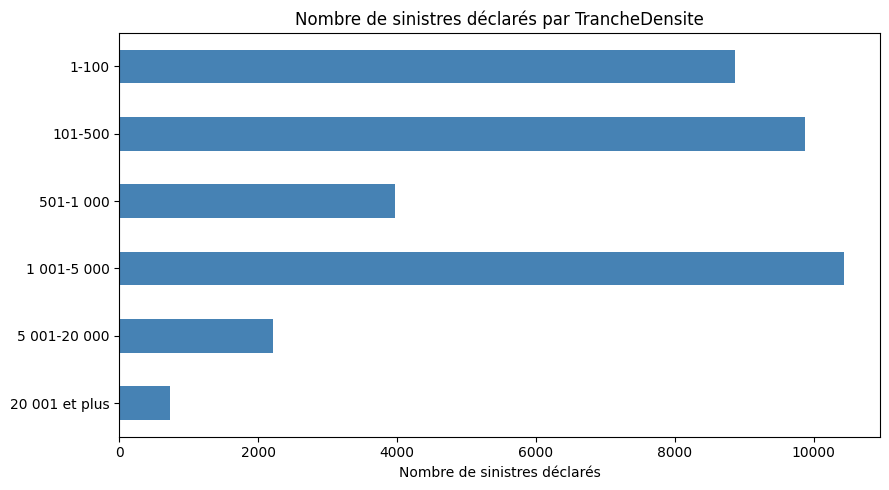

In [6]:
tableaux_tranches = {}

for segment in segments_tranches:
    # observed=True garde les tranches qui contiennent des contrats.
    tableau = df_segments.groupby(segment, as_index=False, observed=True).agg(
        NbContrats=('IDpol', 'count'),
        NbSinistres=('ClaimNb', 'sum'),
        Exposition=('Exposure', 'sum')
    )

    tableau['PartSinistresPct'] = tableau['NbSinistres'] / nb_sinistres_declares * 100
    tableaux_tranches[segment] = tableau

    # Garder les tranches dans leur ordre naturel pour lire les âges et les valeurs.
    print("Analyse par", segment)
    print(tableau.round(2).to_string(index=False))
    print("Contrats conservés :", tableau['NbContrats'].sum() == nb_contrats)
    print("Sinistres conservés :", tableau['NbSinistres'].sum() == nb_sinistres_declares)

    tableau.plot.barh(
        x=segment, y='NbSinistres', legend=False,
        figsize=(9, 5), color='steelblue'
    )
    plt.title(f"Nombre de sinistres déclarés par {segment}")
    plt.xlabel("Nombre de sinistres déclarés")
    plt.ylabel("")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

**Premiers constats :**

- Les conducteurs de **45 à 54 ans** concentrent **9 513 sinistres**, soit **26,35 %** du total.
- Les véhicules de **6 à 10 ans** représentent **27,27 %** des sinistres.
- La tranche de bonus-malus **50 ou moins** représente **50,01 %** des sinistres. Elle contient aussi une grande partie des contrats.

Tous les contrats ont une tranche et les **36 102 sinistres** sont conservés dans chaque regroupement.
Cette première analyse permet de repérer les groupes qui pèsent le plus dans le nombre de sinistres.
La suite consiste à comparer ces nombres à l'exposition des groupes.

# 4. Quels segments ont une fréquence plus élevée ?

Je rapporte maintenant le nombre de sinistres à l'exposition de chaque groupe :
**fréquence = nombre de sinistres / exposition × 100**.
L'unité est le nombre de sinistres pour 100 années d'exposition, pas un pourcentage de contrats.

Je garde les nombres de contrats et de sinistres à côté du ratio.
Pour repérer les très petits groupes, je signale ceux qui ont moins de **1 000 années d'exposition**.
Ce seuil est un choix de lecture pour cette exploration, pas une garantie de fiabilité statistique.

In [7]:
# Réunir les tableaux déjà calculés, sans modifier les originaux.
tableaux_depart = tableaux_categories.copy()
tableaux_depart.update(tableaux_tranches)

seuil_exposition = 1000
tableaux_frequences = {}

for segment, tableau_depart in tableaux_depart.items():
    tableau = tableau_depart.copy()
    tableau['Frequence100'] = tableau['NbSinistres'] / tableau['Exposition'] * 100
    tableau['PartExpositionPct'] = tableau['Exposition'] / exposition_totale * 100
    tableau['ExpositionFaible'] = tableau['Exposition'] < seuil_exposition
    tableaux_frequences[segment] = tableau

    print("Fréquence par", segment)
    print(tableau.round(2).to_string(index=False))

Fréquence par VehGas
 VehGas  NbContrats  NbSinistres  Exposition  PartSinistresPct  Frequence100  PartExpositionPct  ExpositionFaible
Regular      345877        19454   187838.55             53.89         10.36               52.4             False
 Diesel      332136        16648   170660.89             46.11          9.76               47.6             False
Fréquence par Area
Area  NbContrats  NbSinistres  Exposition  PartSinistresPct  Frequence100  PartExpositionPct  ExpositionFaible
   C      191880         9875   104449.00             27.35          9.45              29.14             False
   D      151596         8428    77120.19             23.34         10.93              21.51             False
   E      137167         7805    63819.31             21.62         12.23              17.80             False
   A      103957         5063    61969.38             14.02          8.17              17.29             False
   B       75459         3800    43012.32             10.53    

**Ce que je constate :**

- **Regular : 10,36**, contre **9,76** pour Diesel. L'écart brut est limité et ne prouve pas un effet du carburant.
- Les **18-24 ans** ont une fréquence de **18,93**, contre **10,07** pour le portefeuille. Ce groupe compte **30 198 contrats** et **2 364 sinistres**.
- Le bonus-malus **50 ou moins** concentre beaucoup de sinistres, mais sa fréquence est de **8,02**. La tranche **101-125** atteint **36,83**, avec **1 178 sinistres** et **3 198,27 années d'exposition**.
- **R24** représente **25,49 % des sinistres**, mais **28,65 % de l'exposition**. Sa fréquence est de **8,96**, sous la moyenne du portefeuille. **R11** est à **13,17**, avec **30 208,64 années d'exposition**.
- Les véhicules âgés de **0 an** ont une fréquence de **31,13**. Ce segment mérite aussi un contrôle de ses données avant d'en tirer une conclusion métier.

La tranche de bonus-malus **201 et plus** affiche **253,16 sinistres pour 100 années**, mais repose seulement sur **4 contrats**, **2 sinistres** et environ **0,79 année d'exposition**.
Ce résultat illustre pourquoi il faut regarder les volumes derrière le ratio.

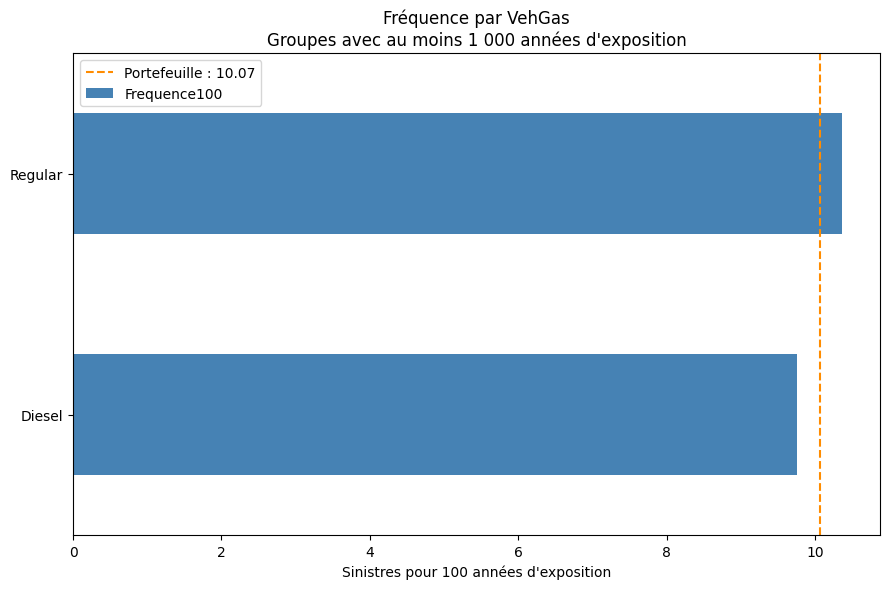

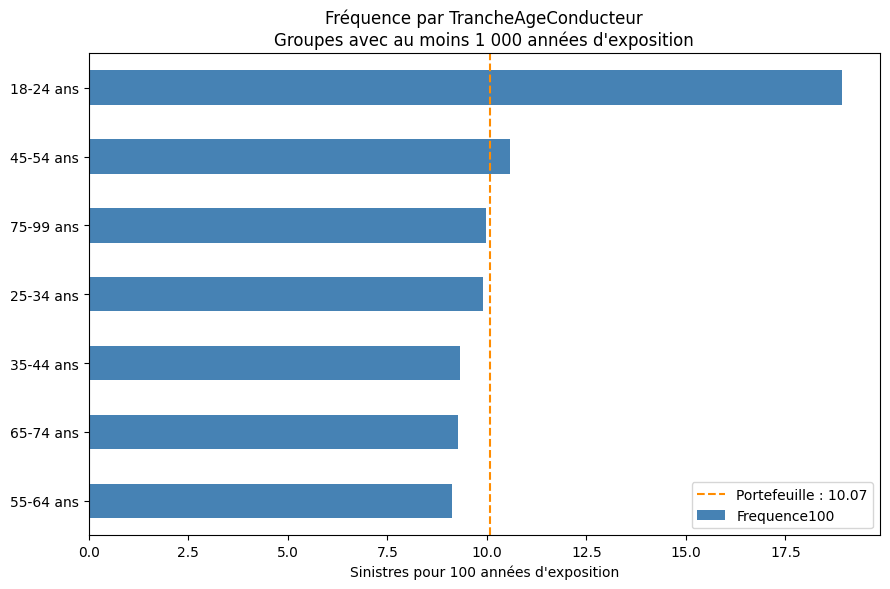

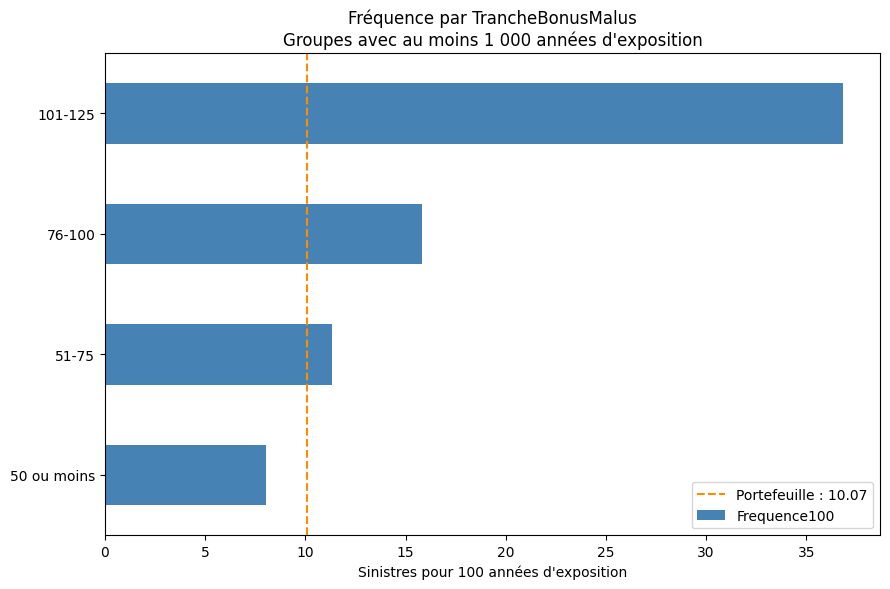

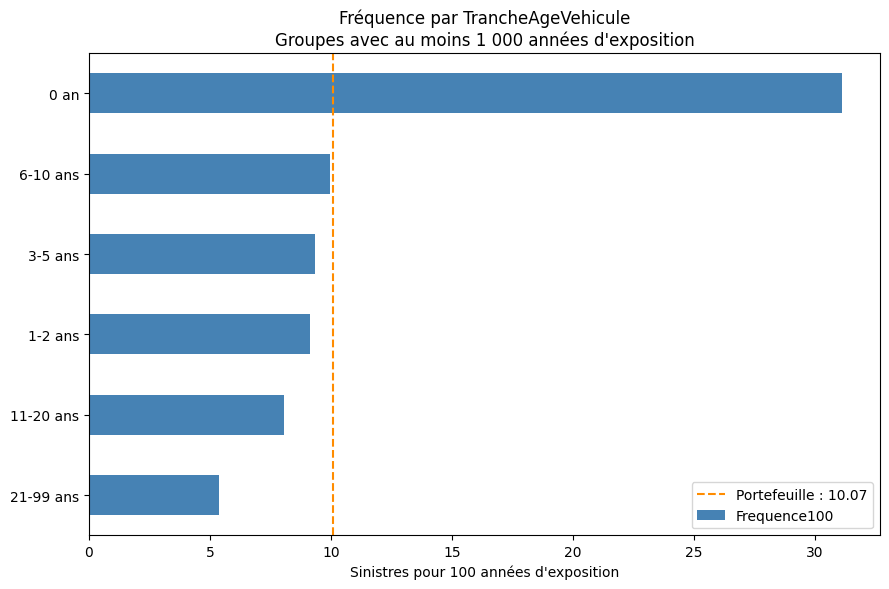

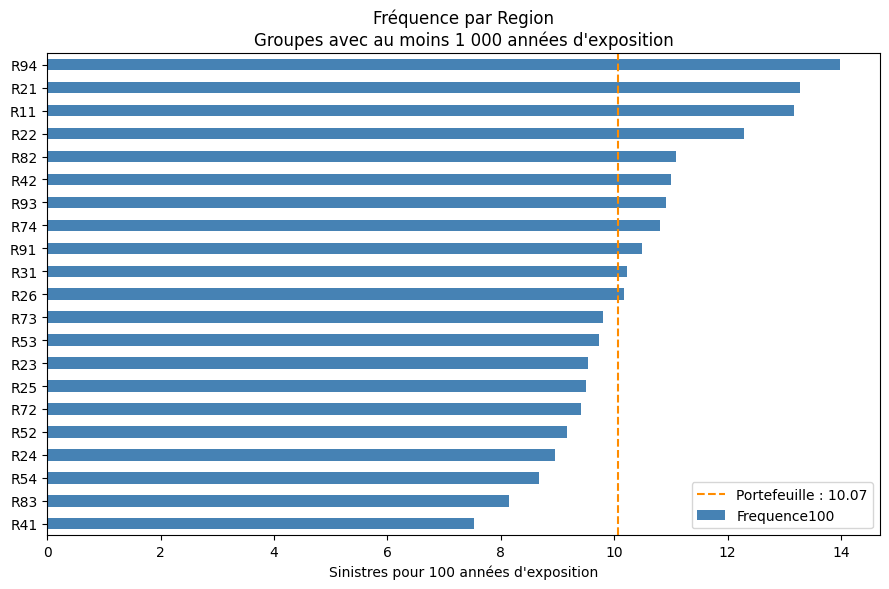

In [8]:
segments_a_afficher = [
    'VehGas', 'TrancheAgeConducteur', 'TrancheBonusMalus',
    'TrancheAgeVehicule', 'Region'
]

for segment in segments_a_afficher:
    tableau = tableaux_frequences[segment]

    # Le filtre concerne seulement le graphique. Tous les groupes restent dans les tableaux.
    graphique = tableau.loc[tableau['Exposition'] >= seuil_exposition].copy()
    graphique = graphique.sort_values('Frequence100', ascending=False)
    graphique.plot.barh(
        x=segment, y='Frequence100', legend=False,
        figsize=(9, 6), color='steelblue'
    )
    plt.axvline(
        frequence100, color='darkorange', linestyle='--',
        label=f"Portefeuille : {frequence100:.2f}"
    )
    plt.title(f"Fréquence par {segment}\nGroupes avec au moins 1 000 années d'exposition")
    plt.xlabel("Sinistres pour 100 années d'exposition")
    plt.ylabel("")
    plt.gca().invert_yaxis()
    plt.legend()
    plt.tight_layout()
    plt.show()

# 5. Où se concentrent les coûts observés ?

Pour les coûts moyens et médians, je repars des **sinistres individuels de sev rapprochables**.
La médiane des totaux par contrat ne donnerait pas la médiane des montants par sinistre.

Je rattache les segments à chaque sinistre. Cette table sert uniquement aux coûts par sinistre :
les fréquences et l'exposition continuent à venir de la table des contrats.

In [9]:
segments_analyse = segments_categories + segments_tranches

# Ajouter les caractéristiques du contrat à chaque sinistre observé.
# Plusieurs sinistres peuvent correspondre à un contrat : many_to_one.
df_sinistres = df_sev_rapprochable.merge(
    df_segments[['IDpol'] + segments_analyse],
    on='IDpol', how='left', validate='many_to_one'
)

print("Nombre de sinistres observés :", len(df_sinistres))
print("Nombre de lignes conservé :", len(df_sinistres) == len(df_sev_rapprochable))
print("Montant conservé :", round(df_sinistres['ClaimAmount'].sum(), 2) == round(montant_observe, 2))
print("Sinistres sans segment attribué :")
print(df_sinistres[segments_analyse].isna().sum())

Nombre de sinistres observés : 26444
Nombre de lignes conservé : True
Montant conservé : True
Sinistres sans segment attribué :
VehGas                  0
Area                    0
VehBrand                0
Region                  0
TrancheAgeConducteur    0
TrancheAgeVehicule      0
TrancheBonusMalus       0
TranchePuissance        0
TrancheDensite          0
dtype: int64


Je calcule les montants, leur part dans le total rapproché, la moyenne et la médiane par sinistre observé.
J'ajoute la part des **contrats sinistrés sans montant retrouvé**, car la couverture des coûts peut varier selon les groupes.
Le contrat avec un nombre de sinistres différent est compté séparément.

In [10]:
# Ces colonnes True/False permettent de compter les situations par groupe.
df_segments['ContratSinistre'] = df_segments['ClaimNb'] > 0
df_segments['SansMontant'] = df_segments['Status'] == 'Montant non retrouvé'
df_segments['EcartNombre'] = df_segments['Status'] == 'Nombre différent'

tableaux_couts = {}

for segment in segments_analyse:
    qualite = df_segments.groupby(segment, as_index=False, observed=True).agg(
        NbContratsSinistres=('ContratSinistre', 'sum'),
        NbSansMontant=('SansMontant', 'sum'),
        NbEcartNombre=('EcartNombre', 'sum')
    )

    couts = df_sinistres.groupby(segment, as_index=False, observed=True).agg(
        NbSinistresObserves=('ClaimAmount', 'size'),
        MontantObserve=('ClaimAmount', 'sum'),
        CoutMoyenObserve=('ClaimAmount', 'mean'),
        CoutMedianObserve=('ClaimAmount', 'median')
    )

    # Garder tous les groupes, même ceux sans montant observé.
    tableau = tableaux_frequences[segment].merge(
        qualite, on=segment, how='left', validate='one_to_one'
    )
    tableau = tableau.merge(couts, on=segment, how='left', validate='one_to_one')

    # Zéro ligne observée ne signifie pas un coût nul : seuls les nombres de lignes sont remplis.
    tableau['NbSinistresObserves'] = tableau['NbSinistresObserves'].fillna(0).astype(int)
    tableau['PartMontantPct'] = tableau['MontantObserve'] / montant_observe * 100
    tableau['CoutObserveParAnnee'] = tableau['MontantObserve'] / tableau['Exposition']

    # Sans contrat sinistré dans un groupe, ce pourcentage n'est pas défini.
    tableau['SansMontantPct'] = (
        tableau['NbSansMontant'] / tableau['NbContratsSinistres'].replace(0, np.nan) * 100
    )
    tableaux_couts[segment] = tableau

# Afficher les principaux tableaux. Les autres restent dans tableaux_couts.
segments_couts_a_afficher = [
    'VehGas', 'TrancheAgeConducteur', 'TrancheAgeVehicule',
    'TrancheBonusMalus', 'VehBrand', 'Region'
]

for segment in segments_couts_a_afficher:
    print("Coûts observés par", segment)
    colonnes = [
        segment, 'NbSinistresObserves', 'MontantObserve', 'PartMontantPct',
        'CoutMoyenObserve', 'CoutMedianObserve', 'SansMontantPct'
    ]
    print(tableaux_couts[segment][colonnes].round(2).to_string(index=False))

Coûts observés par VehGas
 VehGas  NbSinistresObserves  MontantObserve  PartMontantPct  CoutMoyenObserve  CoutMedianObserve  SansMontantPct
Regular                12994     32314542.55           53.94           2486.88             1172.0           33.28
 Diesel                13450     27594673.95           46.06           2051.65             1172.0           19.15
Coûts observés par TrancheAgeConducteur
        TrancheAgeConducteur  NbSinistresObserves  MontantObserve  PartMontantPct  CoutMoyenObserve  CoutMedianObserve  SansMontantPct
                   18-24 ans                 2011     11741344.21           19.60           5838.56            1172.00           14.75
                   25-34 ans                 4973      9957419.91           16.62           2002.30            1128.12           22.25
                   35-44 ans                 6192     12284481.34           20.51           1983.93            1167.46           23.90
                   45-54 ans                 6802   

**Ce que je constate :**

- **R24** concentre **19,07 millions d'euros**, soit **31,84 % des coûts observés**. Sa fréquence reste inférieure à celle du portefeuille : volume de coûts et fréquence ne donnent pas le même classement.
- Les véhicules de **11 à 20 ans** représentent **34,75 % des coûts observés**, contre **26,38 %** pour ceux de 6 à 10 ans. Il faut regarder les gros sinistres avant d'interpréter cet écart.
- Pour les **18-24 ans**, le coût moyen observé est de **5 838,56 €**, mais la médiane est de **1 172 €**. Des montants élevés influencent donc la moyenne ; je les examine plus bas.

Les pourcentages de montants portent sur les **59 909 216,50 € rapprochables**.
Ces coûts sont incomplets et les groupes n'ont pas tous la même couverture. Je ne les présente pas comme leur coût réel complet ou leur rentabilité.
Les `NaN` de coût signalent qu'aucun montant n'est disponible pour le groupe ; un taux de couverture `NaN` indique ici l'absence de contrat sinistré pour définir ce taux.

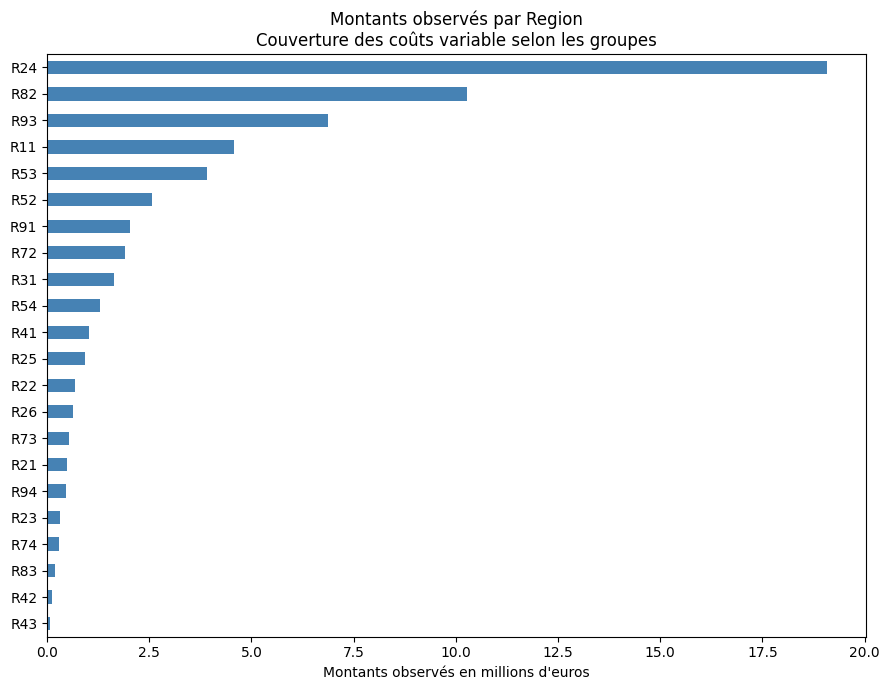

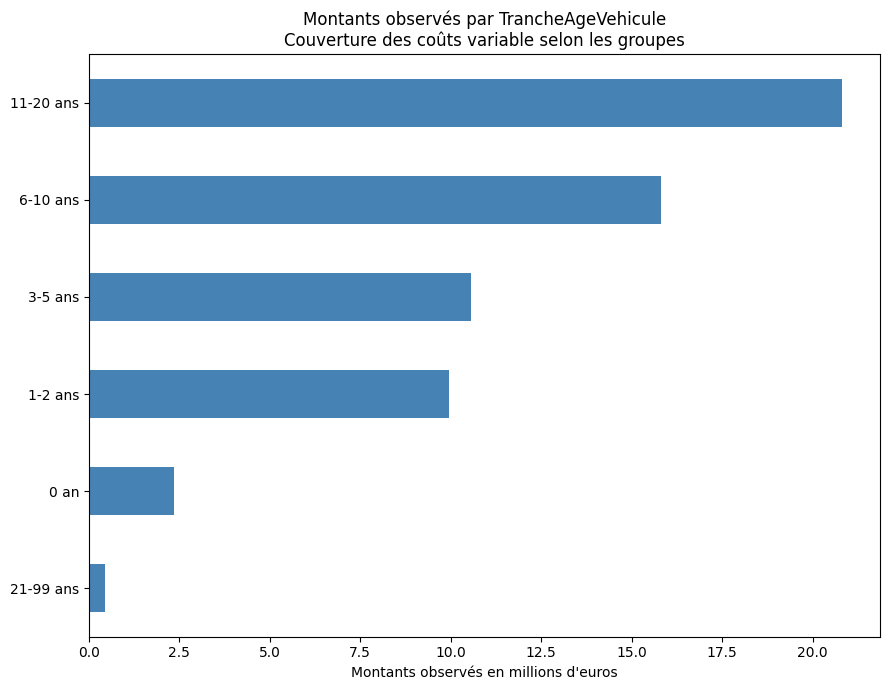

In [11]:
for segment in ['Region', 'TrancheAgeVehicule']:
    # Afficher les groupes pour lesquels un montant est disponible.
    graphique = tableaux_couts[segment].dropna(subset=['MontantObserve']).copy()
    graphique['MontantMillions'] = graphique['MontantObserve'] / 1000000
    graphique = graphique.sort_values('MontantMillions', ascending=False)

    graphique.plot.barh(
        x=segment, y='MontantMillions', legend=False,
        figsize=(9, 7), color='steelblue'
    )
    plt.title(f"Montants observés par {segment}\nCouverture des coûts variable selon les groupes")
    plt.xlabel("Montants observés en millions d'euros")
    plt.ylabel("")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 6. Quels résultats demandent le plus de prudence ?

La part des contrats sinistrés sans montant retrouvé est de **26,76 %** au total, mais elle varie beaucoup :

- **77,51 %** pour les véhicules de **0 an**, contre **14,18 %** pour ceux de 11 à 20 ans ;
- **53,66 %** pour la marque codée **B12** ;
- **33,28 %** pour Regular, contre **19,15 %** pour Diesel.

Je ne peux donc pas supposer que les coûts manquants sont répartis de façon identique entre les groupes.
Pour les véhicules de 0 an et B12, la priorité est de vérifier le périmètre des extractions et la signification des codes.
L'origine des montants non retrouvés reste inconnue.

Ce pourcentage compte les contrats sinistrés entièrement absents de `sev`. Le contrat avec **2 sinistres déclarés contre 1 ligne observée** reste un cas distinct.

          TrancheAgeVehicule  NbContratsSinistres  NbSansMontant  SansMontantPct  NbEcartNombre
                        0 an                 4922           3815           77.51              0
                     1-2 ans                 5329           1075           20.17              1
                     3-5 ans                 6352           1316           20.72              0
                    6-10 ans                 9306           1729           18.58              0
                   11-20 ans                 7894           1119           14.18              0
                   21-99 ans                  257             62           24.12              0
100 ans et plus (à vérifier)                    0              0             NaN              0


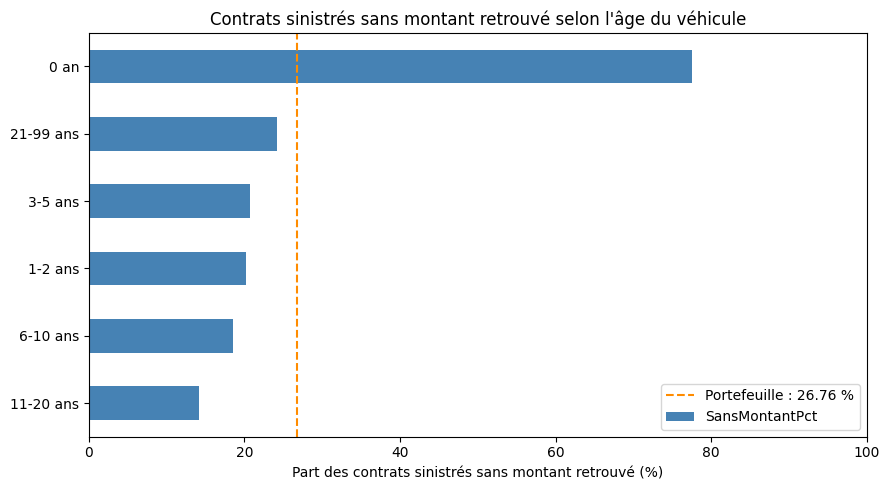

In [12]:
tableau_qualite = tableaux_couts['TrancheAgeVehicule']
print(tableau_qualite[[
    'TrancheAgeVehicule', 'NbContratsSinistres', 'NbSansMontant',
    'SansMontantPct', 'NbEcartNombre'
]].round(2).to_string(index=False))

# Les groupes sans contrat sinistré n'ont pas de pourcentage à afficher.
graphique = tableau_qualite.dropna(subset=['SansMontantPct']).copy()
graphique = graphique.sort_values('SansMontantPct', ascending=False)
graphique.plot.barh(
    x='TrancheAgeVehicule', y='SansMontantPct', legend=False,
    figsize=(9, 5), color='steelblue'
)
plt.axvline(
    part_sans_montant, color='darkorange', linestyle='--',
    label=f"Portefeuille : {part_sans_montant:.2f} %"
)
plt.title("Contrats sinistrés sans montant retrouvé selon l'âge du véhicule")
plt.xlabel("Part des contrats sinistrés sans montant retrouvé (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

# 7. Quel est le poids du plus gros sinistre ?

Je compare les coûts observés avec et sans **le plus gros sinistre**, uniquement pour mesurer son influence.
Je conserve ce sinistre dans les données et dans les KPI de référence : son montant élevé ne prouve pas qu'il est erroné.

In [13]:
index_plus_gros = df_sinistres['ClaimAmount'].idxmax()
plus_gros = df_sinistres.loc[index_plus_gros]

print("Plus gros sinistre observé :")
print(plus_gros[[
    'IDpol', 'ClaimAmount', 'Region', 'VehGas', 'TrancheAgeConducteur'
]])

# Créer une série à part pour cette comparaison seulement.
montants_sans_plus_gros = df_sinistres['ClaimAmount'].drop(index=index_plus_gros)

df_influence = pd.DataFrame({
    'Scenario': ['Tous les sinistres observés', 'Sans le plus gros (diagnostic)'],
    'NbSinistres': [len(df_sinistres), len(montants_sans_plus_gros)],
    'MontantObserve': [df_sinistres['ClaimAmount'].sum(), montants_sans_plus_gros.sum()],
    'CoutMoyen': [df_sinistres['ClaimAmount'].mean(), montants_sans_plus_gros.mean()],
    'CoutMedian': [df_sinistres['ClaimAmount'].median(), montants_sans_plus_gros.median()]
})
print(df_influence.round(2).to_string(index=False))

part_plus_gros = plus_gros['ClaimAmount'] / montant_observe * 100
print(f"Part du plus gros sinistre dans les montants observés : {part_plus_gros:.2f} %")

# Regarder aussi son poids dans sa région.
region_plus_gros = plus_gros['Region']
montants_region = df_sinistres.loc[
    df_sinistres['Region'] == region_plus_gros, 'ClaimAmount'
]
part_dans_region = plus_gros['ClaimAmount'] / montants_region.sum() * 100
moyenne_region_sans_plus_gros = montants_region.drop(index=index_plus_gros).mean()
print(f"Part de ce sinistre dans les montants de {region_plus_gros} : {part_dans_region:.2f} %")
print(f"Coût moyen de {region_plus_gros} avec ce sinistre : {montants_region.mean():.2f} €")
print(f"Coût moyen de {region_plus_gros} sans ce sinistre : {moyenne_region_sans_plus_gros:.2f} €")

Plus gros sinistre observé :
IDpol                      1120377
ClaimAmount             4075400.56
Region                         R24
VehGas                     Regular
TrancheAgeConducteur     18-24 ans
Name: 9756, dtype: object
                      Scenario  NbSinistres  MontantObserve  CoutMoyen  CoutMedian
   Tous les sinistres observés        26444     59909216.50    2265.51      1172.0
Sans le plus gros (diagnostic)        26443     55833815.94    2111.48      1172.0
Part du plus gros sinistre dans les montants observés : 6.80 %
Part de ce sinistre dans les montants de R24 : 21.37 %
Coût moyen de R24 avec ce sinistre : 2945.92 €
Coût moyen de R24 sans ce sinistre : 2316.87 €


Le sinistre de **4 075 400,56 €** représente **6,80 % des montants rapprochés**.
Sans lui, le coût moyen global passe de **2 265,51 € à 2 111,48 €**, tandis que la médiane reste à **1 172 €**.

Il appartient à **R24** et représente **21,37 % des montants observés de cette région**.
Le coût moyen de R24 passe de **2 945,92 € à 2 316,87 €** dans ce diagnostic.
Il appartient également à la tranche **18-24 ans** et contribue à sa moyenne élevée.

Je retiens qu'un seul sinistre peut modifier sensiblement une comparaison de coûts moyens.
Cela justifie d'afficher la médiane et le nombre de sinistres observés à côté de la moyenne.

## Vérification des tableaux de synthèse

Je vérifie que les regroupements conservent les contrats, les sinistres déclarés, les sinistres observés et les montants.
Chaque regroupement est une lecture du même portefeuille : leurs totaux ne doivent pas être additionnés entre eux.

In [14]:
for segment in segments_analyse:
    tableau = tableaux_couts[segment]
    contrats_ok = tableau['NbContrats'].sum() == nb_contrats
    declares_ok = tableau['NbSinistres'].sum() == nb_sinistres_declares
    observes_ok = tableau['NbSinistresObserves'].sum() == nb_sinistres_observes
    montants_ok = round(tableau['MontantObserve'].sum(), 2) == round(montant_observe, 2)
    manquants_ok = tableau['NbSansMontant'].sum() == nb_contrats_sans_montant

    print(segment)
    print("Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :")
    print(contrats_ok, declares_ok, observes_ok, montants_ok, manquants_ok)

VehGas
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
Area
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
VehBrand
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
Region
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
TrancheAgeConducteur
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
TrancheAgeVehicule
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
TrancheBonusMalus
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
TranchePuissance
Contrats, sinistres déclarés, sinistres observés, montants, contrats sans montant :
True True True True True
TrancheDensite
Contrats, 

# 8. Ce que je retiens pour la suite du projet

| Sujet | Constat | Limite | Suite proposée |
|---|---|---|---|
| Qualité des coûts | 77,51 % des contrats sinistrés avec un véhicule de 0 an sont sans montant retrouvé ; 53,66 % pour B12 | La cause de ces absences reste inconnue | Vérifier les extractions et les codes avant de comparer les coûts complets de ces groupes |
| Fréquence | 18,93 sinistres pour 100 années pour les 18-24 ans ; 36,83 pour le bonus-malus 101-125 | Comparaisons descriptives, profils des groupes différents | Croiser l'âge, le bonus-malus et l'exposition pour comprendre ces écarts avant de proposer une action |
| Volume et fréquence | R24 concentre 25,49 % des sinistres, mais sa fréquence est de 8,96 contre 10,07 au global | Le nombre brut dépend du volume d'exposition | Présenter ensemble le volume et la fréquence dans le dashboard |
| Coûts de R24 | 31,84 % des montants observés ; un sinistre représente 21,37 % des montants de la région | Coûts incomplets et moyenne sensible aux gros sinistres | Examiner la nature des gros sinistres et garder moyenne, médiane et effectifs ensemble |

**Ordre de travail proposé :** vérifier d'abord les écarts de données, puis approfondir les segments à fréquence élevée et les gros sinistres.
Ces constats ne démontrent pas de causalité et ne suffisent pas à décider d'une modification de tarif.
Les segments peuvent se recouper : un même contrat appartient à une tranche d'âge, une région et une tranche de bonus-malus.

Les limites du contrôle qualité restent valables : les coûts sont incomplets, les expositions supérieures à un an sont conservées,
les âges de 100 ans restent à vérifier et les répétitions de lignes de sinistres n'ont pas été supprimées.

## Préparation du tableau de bord

| Page | Contenu proposé | Résultats disponibles dans le notebook |
|---|---|---|
| Vue d'ensemble | Taille du portefeuille, exposition, fréquence et montants observés, avec le taux de contrats sinistrés sans montant | df_kpi |
| Comparaison des segments | Fréquence avec volumes, montants observés, coûts moyen et médian, couverture des coûts | tableaux_frequences et tableaux_couts |
| Qualité et limites | Montants non retrouvés par segment, orphelins, écart de nombre de sinistres et influence du plus gros montant | tableaux_couts, df_sev_orphelins et df_influence |

Pour Power BI, les fréquences seront calculées à partir de la table par contrat.
Les moyennes et médianes des coûts par sinistre utiliseront les montants individuels rapprochés.
Je garderai les mêmes tranches et vérifierai les KPI avec les chiffres de ce notebook.
Les tables ne contiennent pas de dates permettant de construire une évolution mensuelle.